In [1]:
import fastf1 as ff1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utility import set_dark

# local cache to avoid repeated downloads
ff1.Cache.enable_cache('./data/cache')

In [2]:
session = ff1.get_session(2025, 'Mexico', 'R')

session.load()

core           INFO 	Loading data for Mexico City Grand Prix - Race [v3.6.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '16', '1', '87', '81', '12', '63', '44', '31', '5', '22', '23', '6', '18', '10', '43', '55', '14', '27', '30']


# Would Verstappen have caught Leclerc in the last lap if there had been no VSC ?

- Many fans are furious over the Virtual Safety Car in the last lap, when the battle between Leclerc & Verstappen and Bearman & Piastri was about to happen. 
- As Verstappen was chasing Mclarens for the Championship Title, the 3 points difference between P2 and P3 mattered a lot for him. 

In [3]:
# check when VER last pitted
ver_laps = session.laps.pick_drivers("VER")

ver_pit_laps = ver_laps.loc[ver_laps['PitInTime'].notnull()]
ver_pit_laps

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
36,0 days 01:48:41.709000,VER,1,0 days 00:01:27.255000,37.0,1.0,NaT,0 days 01:48:39.134000,0 days 00:00:29.249000,0 days 00:00:32.963000,...,True,Red Bull Racing,0 days 01:47:14.454000,2025-10-26 20:53:23.229,1,2.0,False,,False,False


VER only pitted once, on __Lap 36__.   
Let's see what compound he changed to.

In [4]:
ver_laps[["LapNumber", "Compound"]].loc[35:38]

,LapNumber,Compound
35,36.0,MEDIUM
36,37.0,MEDIUM
37,38.0,SOFT
38,39.0,SOFT


He changed from __MEDIUM__ to __SOFT__.   
Now, lap times for Verstappen and Leclerc.   

Since we're interested in the battle for P2, investigate when Max got P3.

## Verstappen's Lap Time for last 21 laps.

In [5]:
ver_laps.loc[45:50]

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
45,0 days 02:01:13.837000,VER,1,0 days 00:01:21.681000,46.0,2.0,NaT,NaT,0 days 00:00:28.564000,0 days 00:00:31.839000,...,False,Red Bull Racing,0 days 01:59:52.156000,2025-10-26 21:06:00.931,1,8.0,False,,False,True
46,0 days 02:02:35.073000,VER,1,0 days 00:01:21.236000,47.0,2.0,NaT,NaT,0 days 00:00:28.278000,0 days 00:00:31.925000,...,False,Red Bull Racing,0 days 02:01:13.837000,2025-10-26 21:07:22.612,1,5.0,False,,False,True
47,0 days 02:03:56.508000,VER,1,0 days 00:01:21.435000,48.0,2.0,NaT,NaT,0 days 00:00:28.691000,0 days 00:00:31.692000,...,False,Red Bull Racing,0 days 02:02:35.073000,2025-10-26 21:08:43.848,1,5.0,False,,False,True
48,0 days 02:05:17.727000,VER,1,0 days 00:01:21.219000,49.0,2.0,NaT,NaT,0 days 00:00:28.693000,0 days 00:00:31.457000,...,False,Red Bull Racing,0 days 02:03:56.508000,2025-10-26 21:10:05.283,1,3.0,False,,False,True
49,0 days 02:06:38.835000,VER,1,0 days 00:01:21.108000,50.0,2.0,NaT,NaT,0 days 00:00:28.637000,0 days 00:00:31.403000,...,False,Red Bull Racing,0 days 02:05:17.727000,2025-10-26 21:11:26.502,1,3.0,False,,False,True
50,0 days 02:08:00.101000,VER,1,0 days 00:01:21.266000,51.0,2.0,NaT,NaT,0 days 00:00:28.693000,0 days 00:00:31.497000,...,False,Red Bull Racing,0 days 02:06:38.835000,2025-10-26 21:12:47.610,1,3.0,False,,False,True


In [6]:
lec_laps = session.laps.pick_drivers("LEC")

lec_laps = lec_laps.reset_index(drop=True)
lec_laps.loc[45:50]

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
45,0 days 02:00:59.229000,LEC,16,0 days 00:01:21.683000,46.0,2.0,NaT,NaT,0 days 00:00:28.498000,0 days 00:00:31.719000,...,True,Ferrari,0 days 01:59:37.546000,2025-10-26 21:05:46.321,1,2.0,False,,False,True
46,0 days 02:02:21.047000,LEC,16,0 days 00:01:21.818000,47.0,2.0,NaT,NaT,0 days 00:00:28.637000,0 days 00:00:32.007000,...,True,Ferrari,0 days 02:00:59.229000,2025-10-26 21:07:08.004,1,2.0,False,,False,True
47,0 days 02:03:43.022000,LEC,16,0 days 00:01:21.975000,48.0,2.0,NaT,NaT,0 days 00:00:28.668000,0 days 00:00:32.014000,...,True,Ferrari,0 days 02:02:21.047000,2025-10-26 21:08:29.822,1,2.0,False,,False,True
48,0 days 02:05:04.795000,LEC,16,0 days 00:01:21.773000,49.0,2.0,NaT,NaT,0 days 00:00:28.698000,0 days 00:00:31.847000,...,True,Ferrari,0 days 02:03:43.022000,2025-10-26 21:09:51.797,1,2.0,False,,False,True
49,0 days 02:06:26.806000,LEC,16,0 days 00:01:22.011000,50.0,2.0,NaT,NaT,0 days 00:00:28.615000,0 days 00:00:32.101000,...,True,Ferrari,0 days 02:05:04.795000,2025-10-26 21:11:13.570,1,2.0,False,,False,True
50,0 days 02:07:48.793000,LEC,16,0 days 00:01:21.987000,51.0,2.0,NaT,NaT,0 days 00:00:28.718000,0 days 00:00:31.920000,...,True,Ferrari,0 days 02:06:26.806000,2025-10-26 21:12:35.581,1,2.0,False,,False,True


From __Lap 49__, Max was P3 and Charles was P2. 

In [19]:
ver_laps_2 = ver_laps.loc[48:]
lec_laps_2 = lec_laps.loc[48:]

# ver_laps_2['LapTimeSec'] = ver_laps_2['LapTime'].dt.total_seconds()
# lec_laps_2['LapTimeSec'] = lec_laps_2['LapTime'].dt.total_seconds()
ver_laps = ver_laps.assign(LapTimeSec = ver_laps['LapTime'].dt.total_seconds())
lec_laps = lec_laps.assign(LapTimeSec = lec_laps['LapTime'].dt.total_seconds())

ver_laps_2 = ver_laps_2.assign(LapTimeSec = ver_laps_2['LapTime'].dt.total_seconds())
lec_laps_2 = lec_laps_2.assign(LapTimeSec = lec_laps_2['LapTime'].dt.total_seconds())


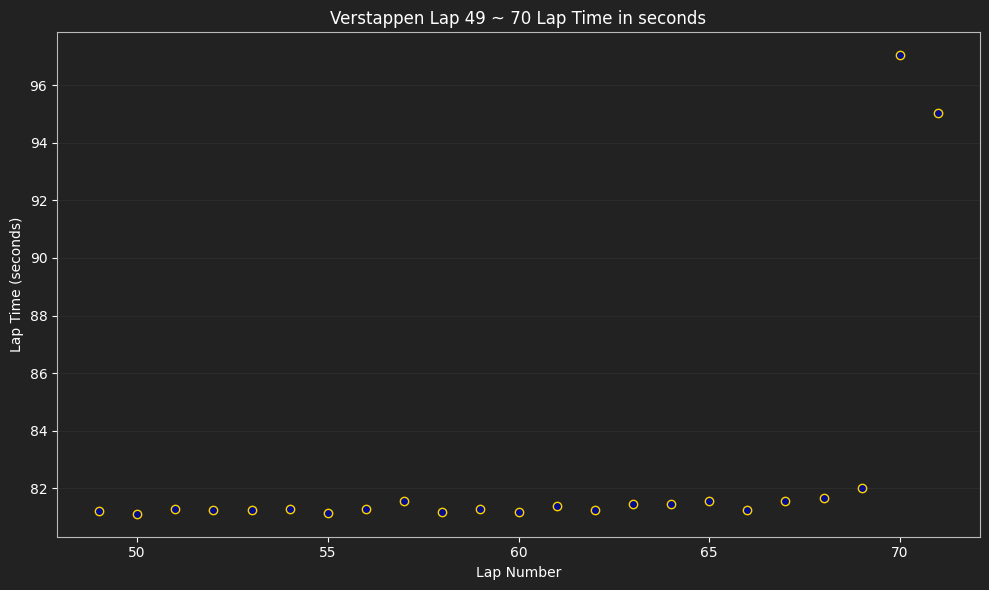

In [17]:
# VER consistency
fig, ax = plt.subplots(figsize=(10, 6))
set_dark(ax)

ax.scatter(x=ver_laps_2['LapNumber'], y=ver_laps_2['LapTimeSec'], color='#000B8D', edgecolors='#FFD300')

ax.set_xlabel('Lap Number')
ax.set_ylabel('Lap Time (seconds)')
ax.set_title("Verstappen Lap 49 ~ 70 Lap Time in seconds")

ax.grid(axis='y', color='gray', linestyle='-', alpha=0.1)

plt.tight_layout()
plt.show()

The scatterplot shows __VER__ was very consistent with old __SOFT__ tyres that was more than 20-laps old. 

In [9]:
ver_laps_2.columns

Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate', 'LapTimeSec'],
      dtype='object')

## Time Gap between Leclerc & Verstappen

In [ ]:
# CumulativeTime column to compute the Total Time. 
# Compute the full lap data for valid time gap calculation. 
ver_laps['CumulativeTime'] = ver_laps['LapTimeSec'].cumsum()
lec_laps['CumulativeTime'] = lec_laps['LapTimeSec'].cumsum()

ver_laps.tail()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate,LapTimeSec,CumulativeTime
66,0 days 02:29:41.263000,VER,1,0 days 00:01:21.563000,67.0,2.0,NaT,NaT,0 days 00:00:28.625000,0 days 00:00:31.684000,...,0 days 02:28:19.700000,2025-10-26 21:34:28.475,1,3.0,False,,False,True,81.563,5553.887
67,0 days 02:31:02.926000,VER,1,0 days 00:01:21.663000,68.0,2.0,NaT,NaT,0 days 00:00:28.750000,0 days 00:00:31.710000,...,0 days 02:29:41.263000,2025-10-26 21:35:50.038,1,3.0,False,,False,True,81.663,5635.550
68,0 days 02:32:24.933000,VER,1,0 days 00:01:22.007000,69.0,2.0,NaT,NaT,0 days 00:00:28.732000,0 days 00:00:31.792000,...,0 days 02:31:02.926000,2025-10-26 21:37:11.701,12,3.0,False,,False,True,82.007,5717.557
69,0 days 02:34:01.978000,VER,1,0 days 00:01:37.045000,70.0,2.0,NaT,NaT,0 days 00:00:28.939000,0 days 00:00:40.720000,...,0 days 02:32:24.933000,2025-10-26 21:38:33.708,26,3.0,False,,False,False,97.045,5814.602
70,0 days 02:35:36.999000,VER,1,0 days 00:01:35.021000,71.0,2.0,NaT,NaT,0 days 00:00:39.249000,0 days 00:00:34.046000,...,0 days 02:34:01.978000,2025-10-26 21:40:10.753,671,3.0,False,,False,False,95.021,5909.623


In [ ]:
gap = pd.merge(
    ver_laps[['LapNumber', 'CumulativeTime']],
    lec_laps[['LapNumber', 'CumulativeTime']],
    on='LapNumber',
    suffixes=('_VER', '_LEC'))

gap['TimeGap'] = gap['CumulativeTime_VER'] - gap['CumulativeTime_LEC']

gap.tail()

,LapNumber,CumulativeTime_VER,CumulativeTime_LEC,TimeGap
66,67.0,5553.887,5552.598,1.289
67,68.0,5635.550,5634.526,1.024
68,69.0,5717.557,5716.944,0.613
69,70.0,5814.602,5814.186,0.416
70,71.0,5909.623,5908.898,0.725


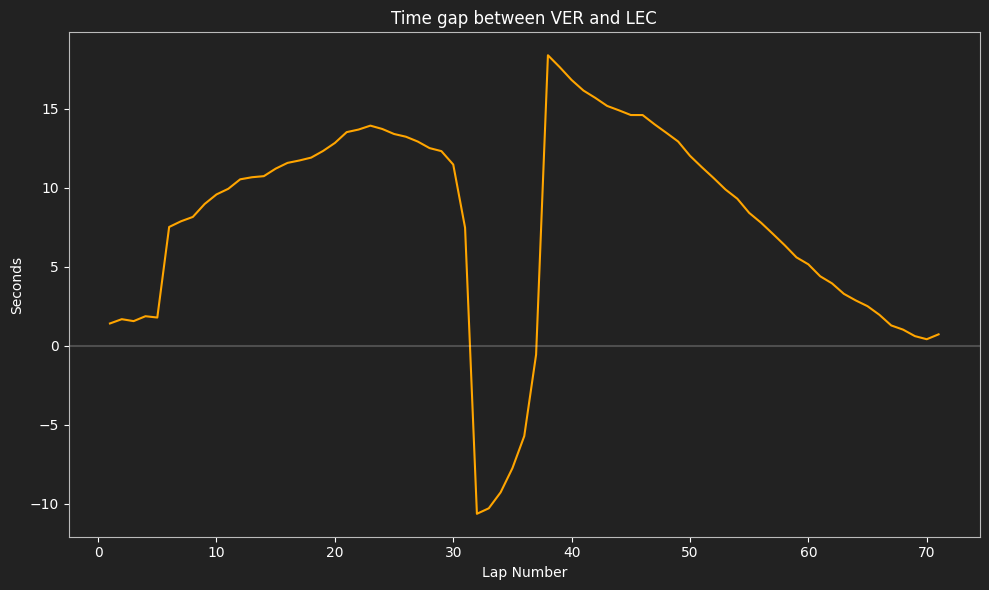

In [48]:
fig, ax = plt.subplots(figsize=(10, 6))
set_dark(ax)

ax.plot(gap['LapNumber'], gap['TimeGap'], color='orange')

ax.set_title('Time gap between VER and LEC')
ax.set_xlabel('Lap Number')
ax.set_ylabel('Seconds')

ax.axhline(y=0, color='white', alpha=0.2)

plt.tight_layout()
plt.show()

- From around lap 40, Verstappen rapidly closed the gap to Leclerc.
- Last take a closer look at lap 60-70. 

In [29]:
gap2 = gap.copy()
gap2 = gap2.loc[gap2['LapNumber'] >= 60]

In [36]:
gap2

,LapNumber,CumulativeTime_VER,CumulativeTime_LEC,TimeGap
59,60.0,4984.047,4978.889,5.158
60,61.0,5065.413,5061.011,4.402
61,62.0,5146.650,5142.699,3.951
62,63.0,5228.084,5224.794,3.290
63,64.0,5309.518,5306.645,2.873
64,65.0,5391.076,5388.569,2.507
65,66.0,5472.324,5470.361,1.963
66,67.0,5553.887,5552.598,1.289
67,68.0,5635.550,5634.526,1.024
68,69.0,5717.557,5716.944,0.613


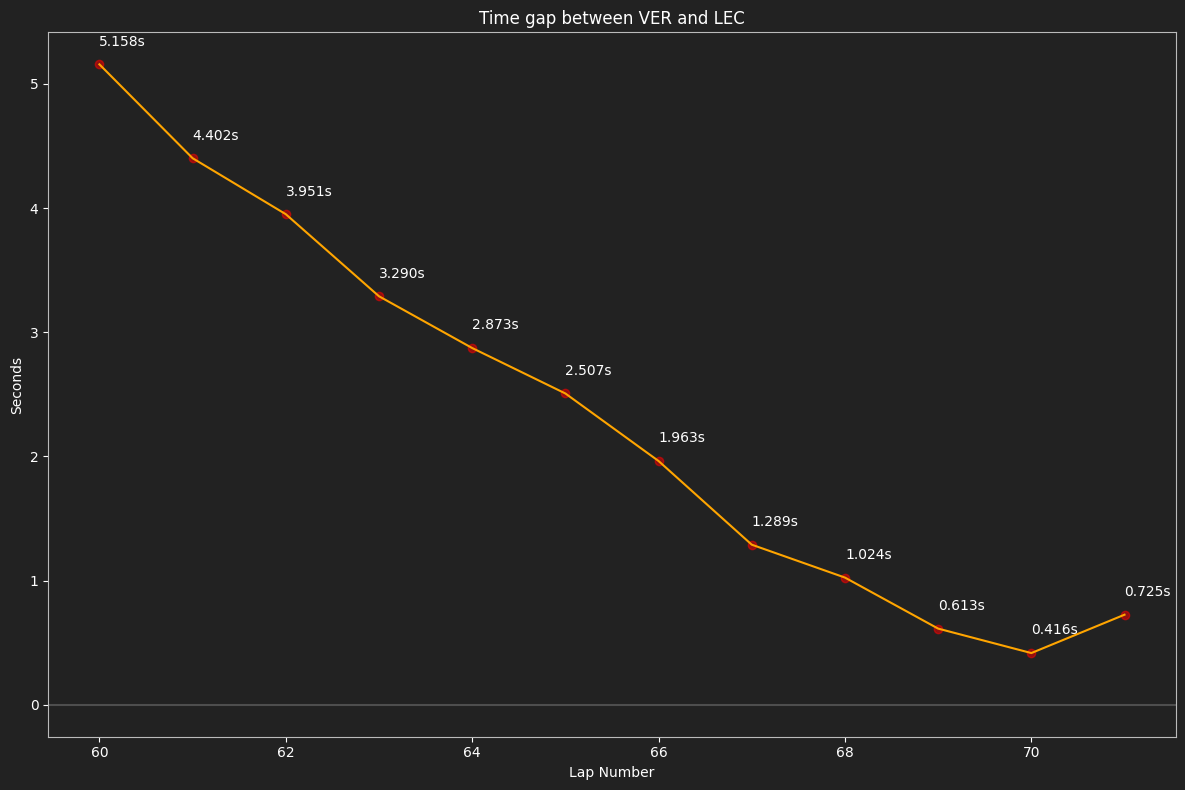

In [49]:
fig, ax = plt.subplots(figsize=(12, 8))
set_dark(ax)

# maybe use seaborn, but used matplotlib to keep the dark theme and consistency.
ax.plot(gap2['LapNumber'], gap2['TimeGap'], color='orange')
ax.scatter(gap2['LapNumber'], gap2['TimeGap'], color='red', alpha=0.5)

# value for each datapoint
for x_val, y_val in zip(gap['LapNumber'], gap['TimeGap']):
    plt.annotate(f"{y_val:.3f}s", (x_val, y_val + 0.15), color='white')

ax.set_title('Time gap between VER and LEC')
ax.set_xlabel('Lap Number')
ax.set_ylabel('Seconds')

ax.axhline(y=0, color='white', alpha=0.2)

plt.tight_layout()
plt.show()

- Verstappen was as close as 0.4 seconds to Leclerc on Lap 70!
- If there had been no VSC, __VER__ might have overtaken __LEC__, achieving 3 more valuable championship points!